In [141]:
import numpy as np
import matplotlib.pyplot as plt
import dynesty as dyn
from dynesty import NestedSampler
from dynesty import plotting as dyplt
import scipy as sp

(100, 3)


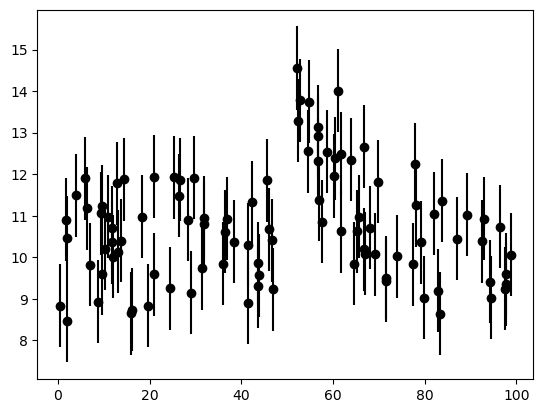

In [142]:
data = np.load('transient.npy')
print(data.shape)
t = data.T[0]
flux = data.T[1]
flux_err = data.T[2]
plt.errorbar(t, flux, flux_err, ls='None', marker='o', c='black')
plt.show()

# Exp burst model

In [191]:
def model (t, theta):
    t0, b, A, logalpha = theta
    alpha = np.exp(logalpha)
    return np.where(t < t0, b, b + A*np.exp(-alpha*(t-t0)))

In [192]:
ndim = int(4)
labels = ['t0', 'b', 'A', 'log(alpha)']

In [193]:
def LogLikelihood (theta, t, flux, flux_err):
    y = model(t, theta)
    return -0.5 * np.sum(((flux - y) / flux_err)**2)

def prior_transform (u):
    theta = np.zeros_like(u)
    theta[0] = u[0]*100 #t0
    theta[1] = u[1]*50 #b
    theta[2] = u[2]*50 #A
    theta[3] = u[3]*10-5 #log(alpha)
    return theta

In [194]:
sampler = NestedSampler(LogLikelihood, prior_transform, ndim, logl_args=(t, flux, flux_err))
sampler.run_nested()
sresults = sampler.results

/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_6285/3478751711.py:4: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A*np.exp(-alpha*(t-t0)))
/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_6285/3478751711.py:4: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t0, b, b + A*np.exp(-alpha*(t-t0)))
 40%|███▉      | 1387/3496 [00:00<00:00, 3838.65it/s, bound: 0 | nc: 85 | ncall: 8202 | eff(%): 16.911 | loglstar: -394.861 | logz: -403.060 +/-  0.123 | dlogz: 316.240 >  0.509] /var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_6285/3478751711.py:4: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A*np.exp(-alpha*(t-t0)))
/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_6285/3478751711.py:4: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t0, b, b + A*np.exp(-alpha*(t-t0)))
 55%|█████▌    | 1785/3240 [00:00<00:00, 2236.92it/s, bound: 1 | nc: 1 | ncall:

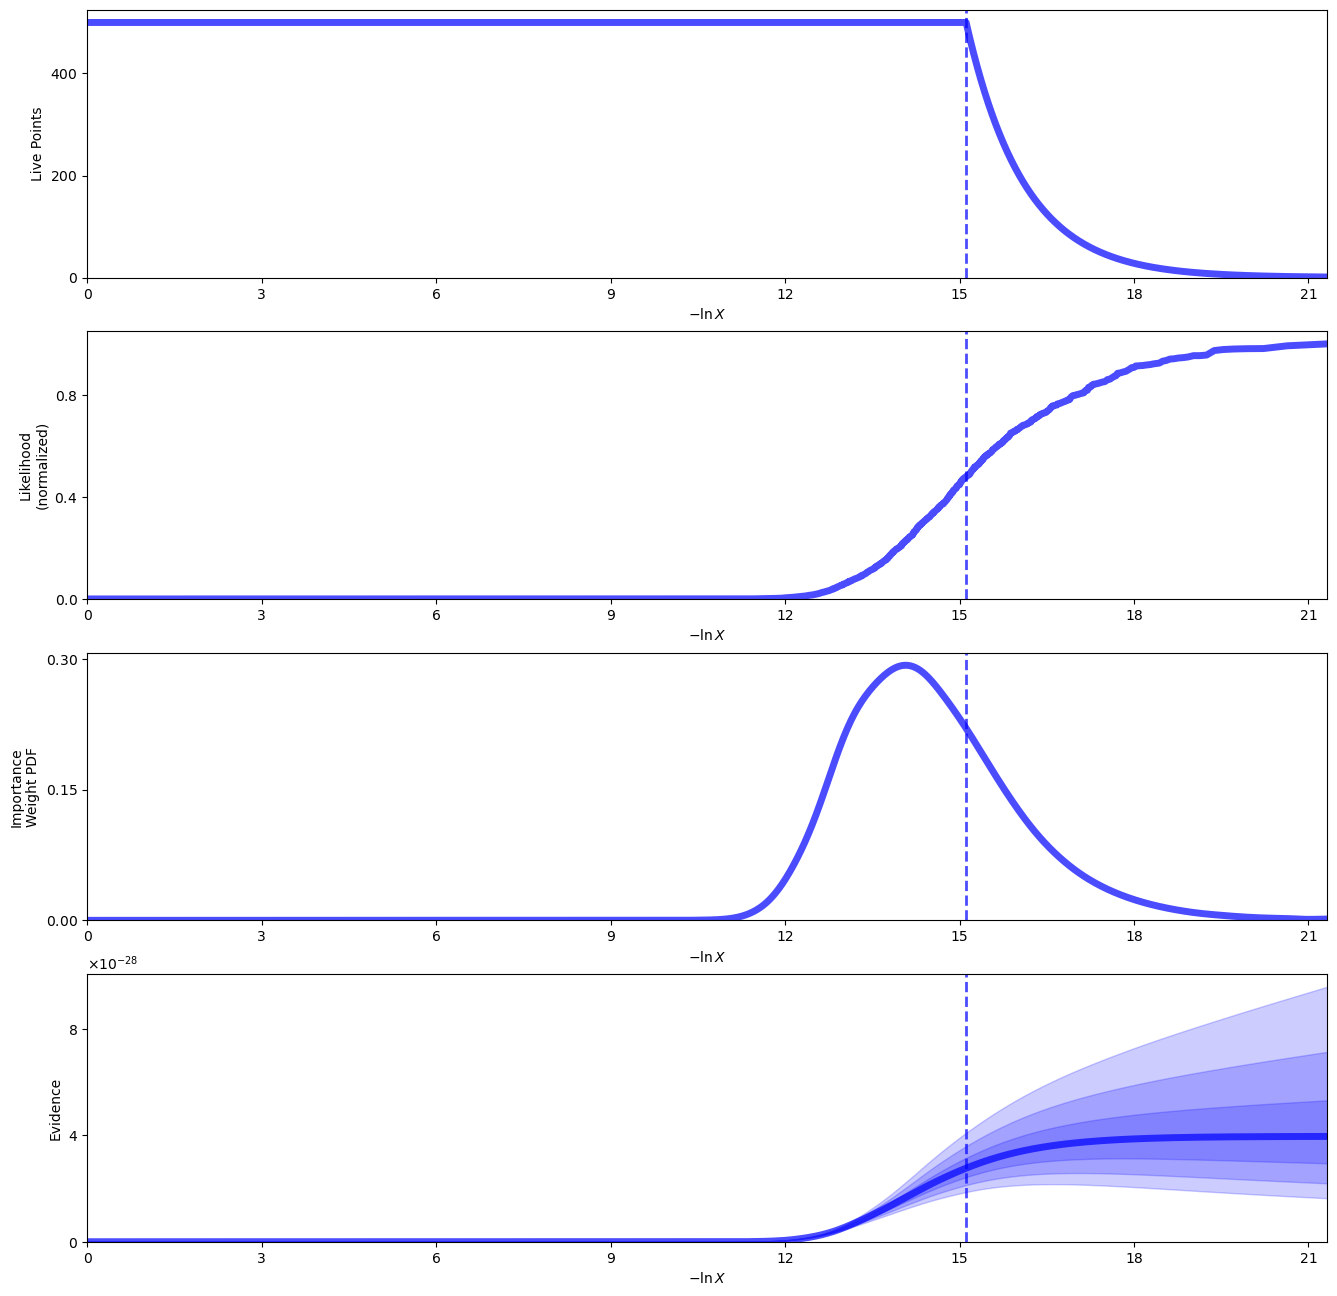

In [195]:
rfig, raxes = dyplt.runplot(sresults)

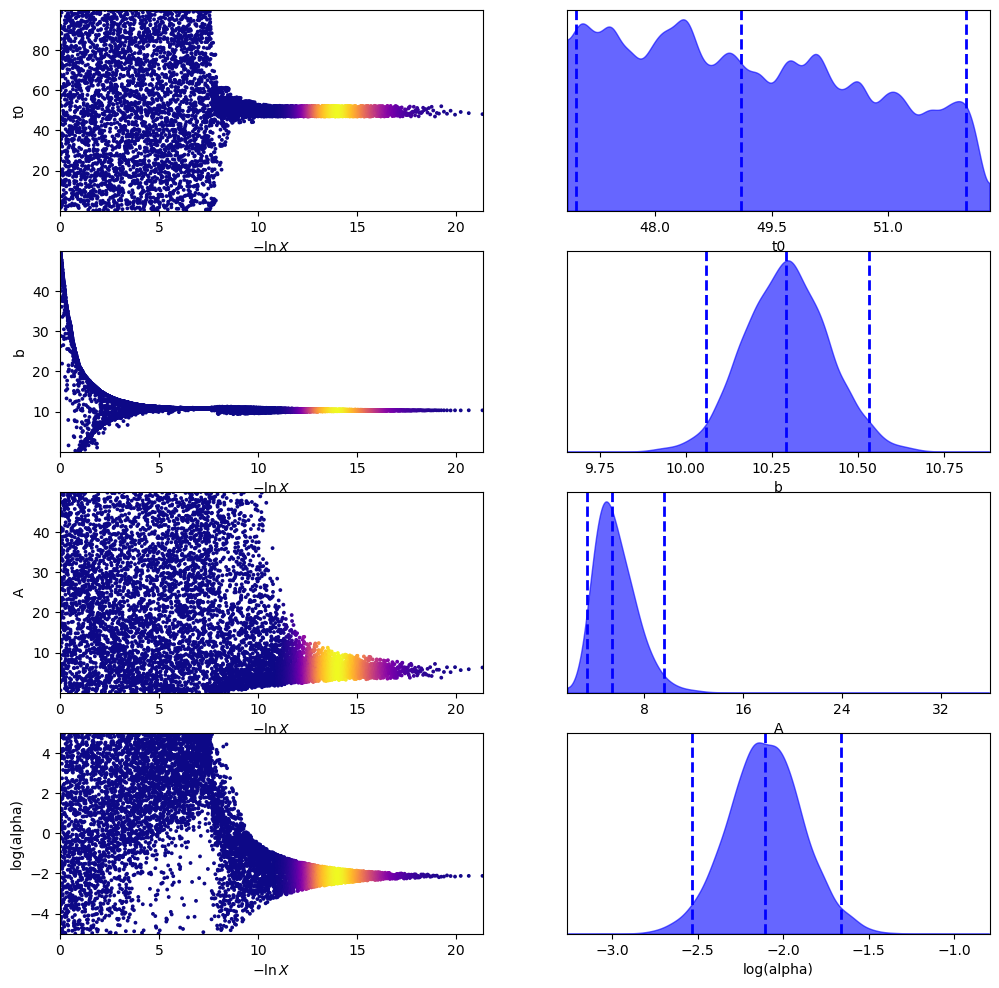

In [196]:
tfig, taxes = dyplt.traceplot(sresults, labels=labels)

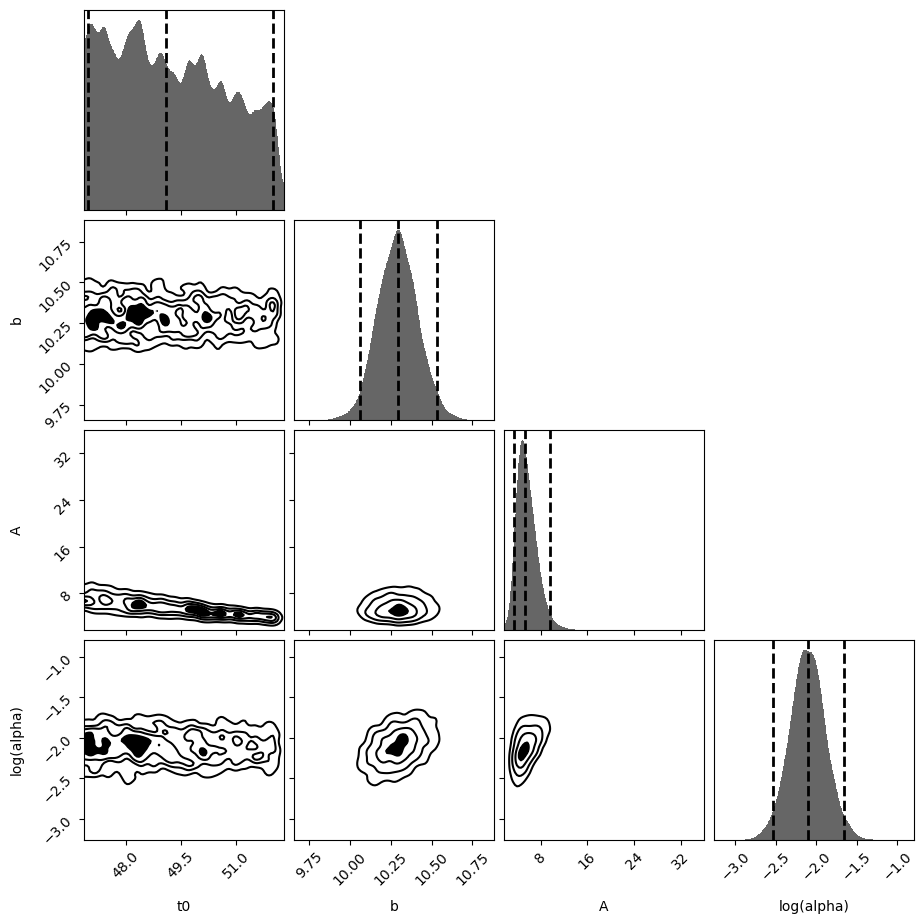

In [197]:
cfig, caxes = dyplt.cornerplot(sresults, labels=labels)

In [198]:
res = sampler.results
samples = res.samples
weights = np.exp(res.logwt - res.logz[-1])
params_est = np.zeros(4)
evidence = sresults.logz[-1]
print('Bayesian evidence:', evidence)
for i in range(4):
    q16, q50, q84 = dyn.utils.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights)    
    print(f"{labels[i]}: {q50:.3f} +{q84-q50:.3f} -{q50-q16:.3f}")
    params_est[i] = q50

Bayesian evidence: -63.09554363894094
t0: 49.106 +1.927 -1.577
b: 10.293 +0.119 -0.121
A: 5.411 +1.808 -1.233
log(alpha): -2.105 +0.213 -0.209


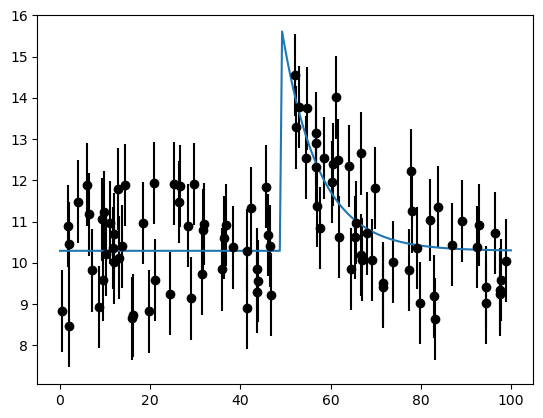

In [199]:
xx = np.linspace(0,100,200)
plt.errorbar(t, flux, flux_err, ls='None', marker='o', c='black')
plt.plot(xx, model(xx, params_est))
plt.show()

# Gaussian model

In [209]:
def model2 (t, theta):
    t0, b, A, sigma = theta
    return b + A * np.exp(- ((t-t0)**2) / (2*sigma**2))

labels = ['t0', 'b', 'A', 'sigma']

In [210]:
def LogLikelihood2 (theta, t, flux, flux_err):
    y = model2(t, theta)
    return -0.5 * np.sum(((flux - y) / flux_err)**2)

def prior_transform2 (u):
    theta = np.zeros_like(u)
    theta[0] = sp.stats.norm.ppf(u[1], loc=50.0, scale=1.0) #t0
    theta[1] = u[1]*20 #b
    theta[2] = sp.stats.norm.ppf(u[1], loc=5.0, scale=1.0) #A
    theta[3] = u[3]*20 #sigma
    return theta

In [211]:
ndim = int(4)

In [212]:
sampler = NestedSampler(LogLikelihood2, prior_transform2, ndim, logl_args=(t, flux, flux_err))
sampler.run_nested()
sresults = sampler.results

100%|█████████▉| 4276/4277 [00:03<00:00, 1166.31it/s, +500 | bound: 13 | nc: 1 | ncall: 25342 | eff(%): 19.226 | loglstar: -74.826 | logz: -82.533 +/-  0.116 | dlogz:  0.001 >  0.509]


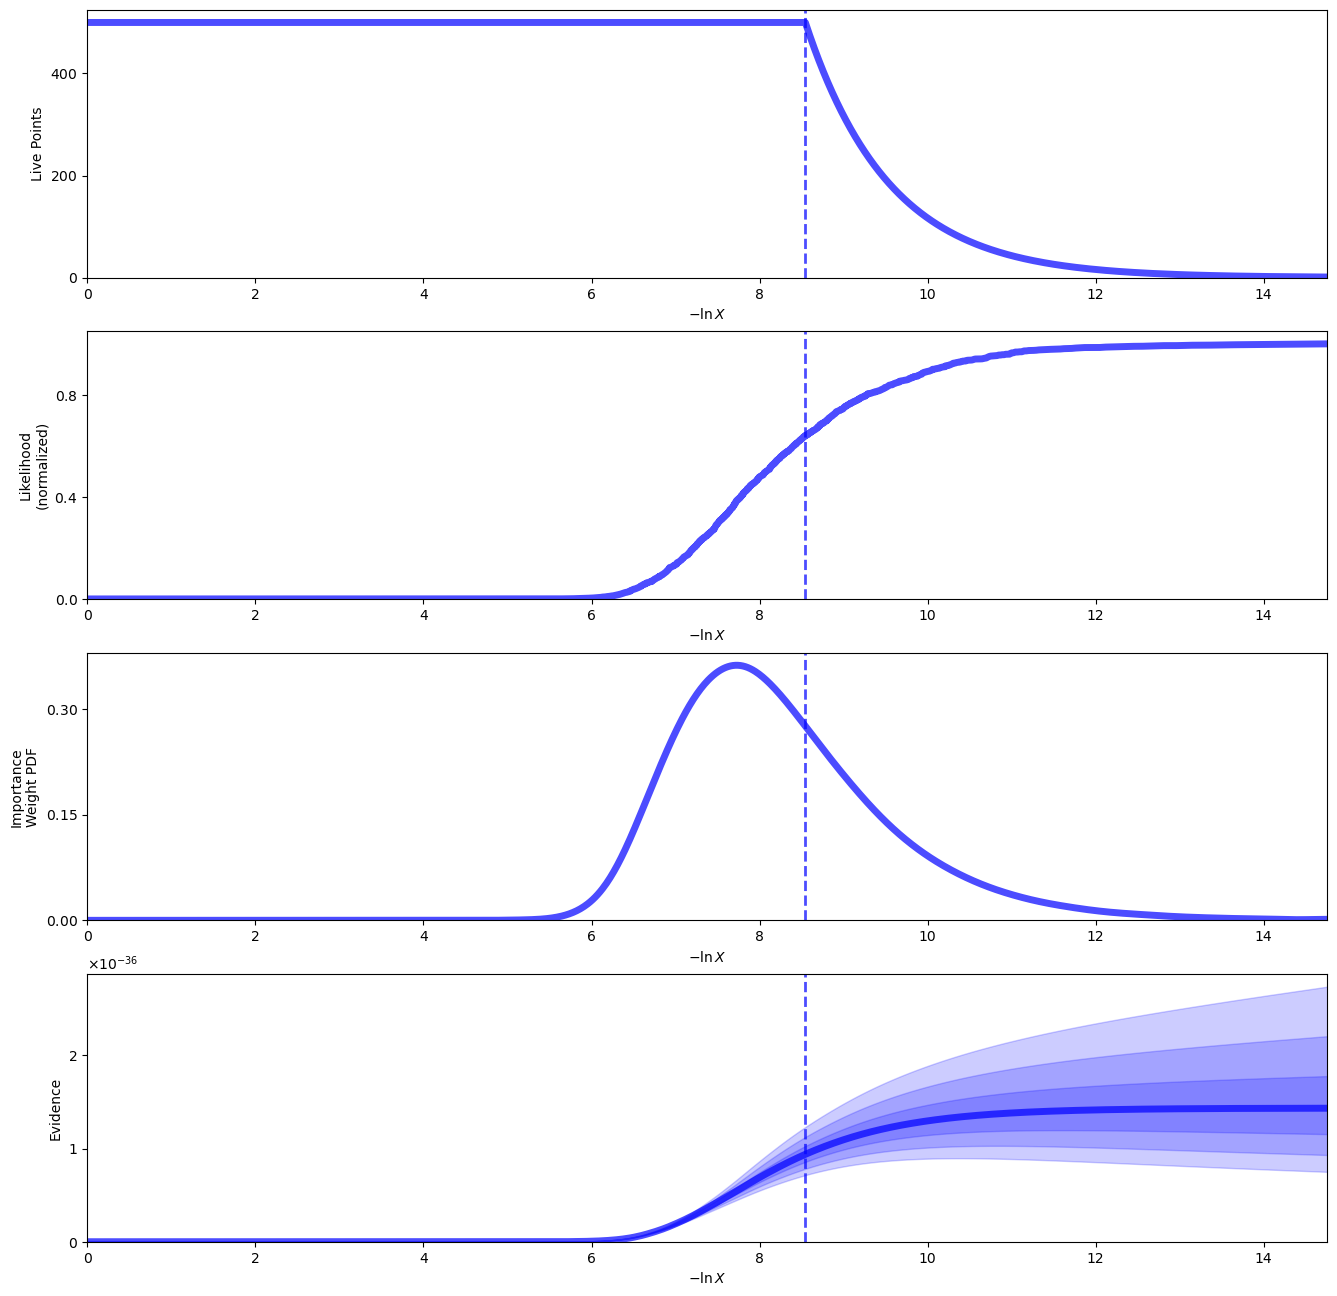

In [213]:
rfig, raxes = dyplt.runplot(sresults)

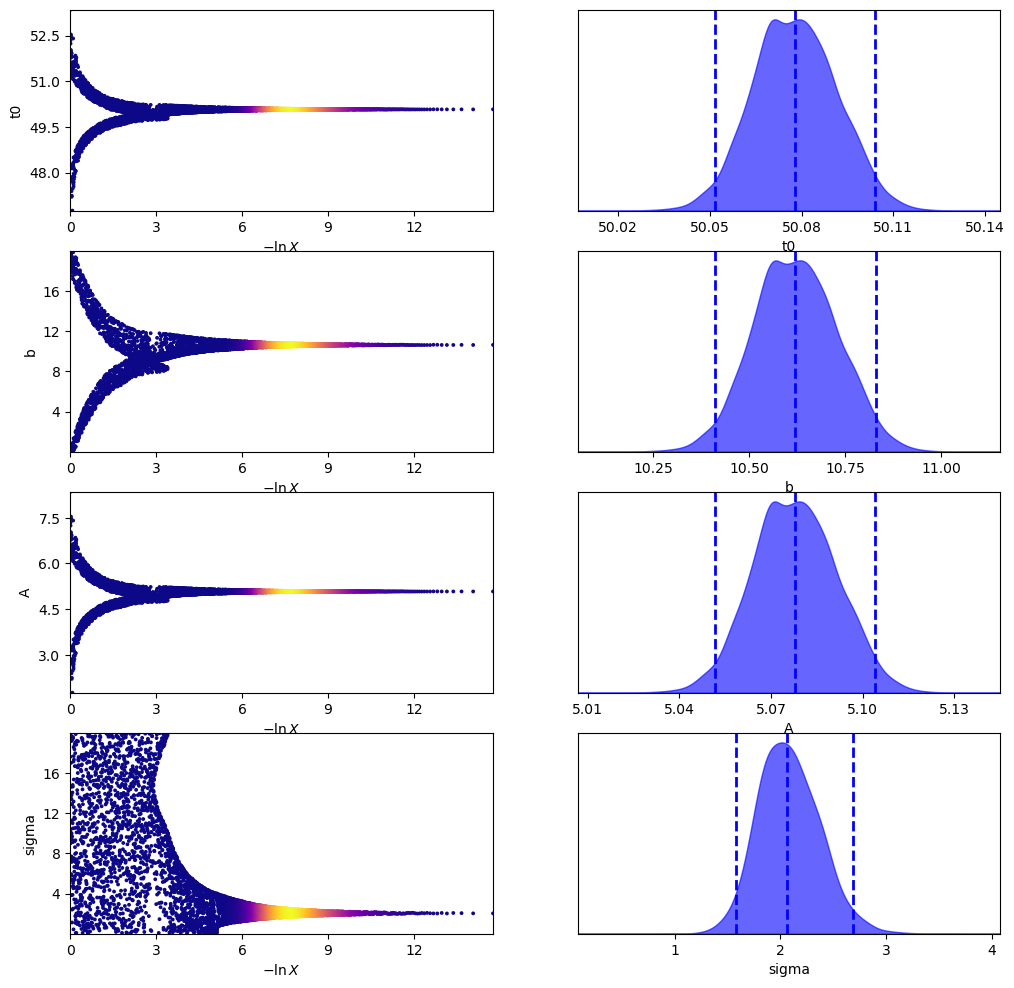

In [214]:
tfig, taxes = dyplt.traceplot(sresults, labels=labels)

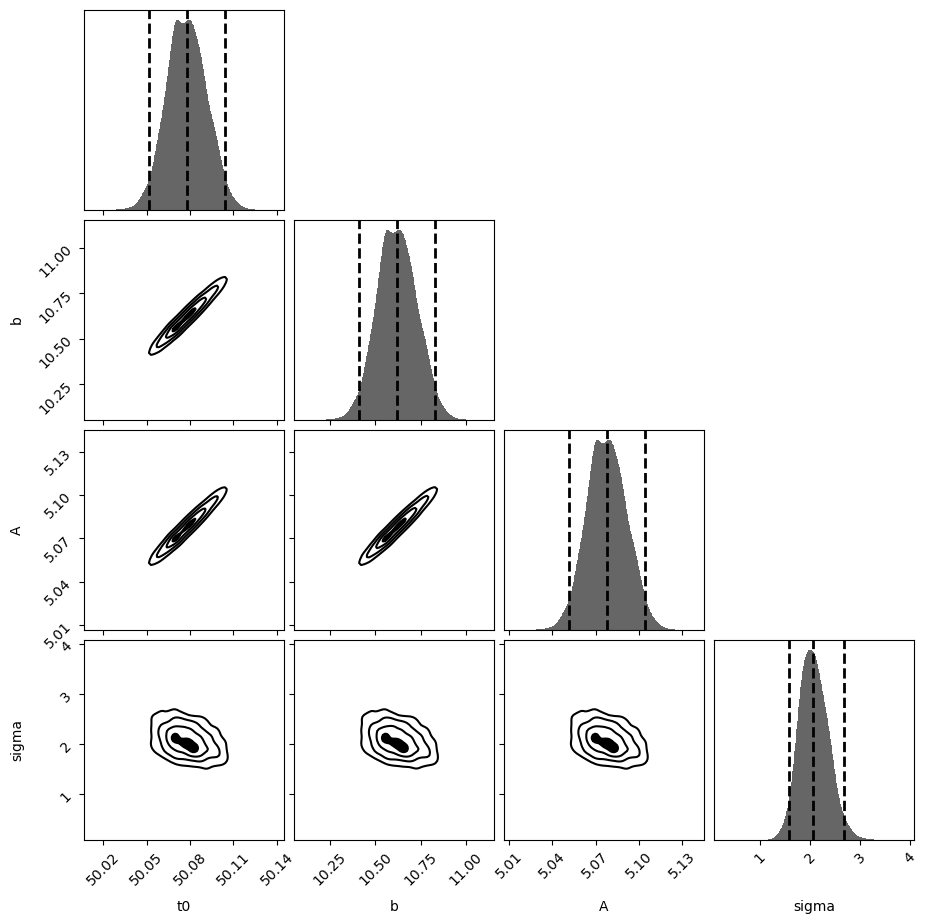

In [215]:
cfig, caxes = dyplt.cornerplot(sresults, labels=labels)

In [216]:
res = sampler.results
samples = res.samples
weights = np.exp(res.logwt - res.logz[-1])
params_est = np.zeros(4)
evidence = sresults.logz[-1]
print('Bayesian evidence:', evidence)

for i in range(4):
    q16, q50, q84 = dyn.utils.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights)    
    print(f"{labels[i]}: {q50:.3f} +{q84-q50:.3f} -{q50-q16:.3f}")
    params_est[i] = q50


Bayesian evidence: -82.53335310889783
t0: 50.078 +0.014 -0.013
b: 10.620 +0.107 -0.106
A: 5.078 +0.014 -0.013
sigma: 2.064 +0.310 -0.262


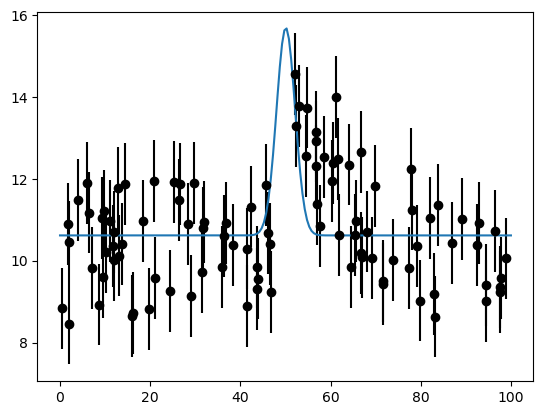

In [217]:
xx = np.linspace(0,100,200)
plt.errorbar(t, flux, flux_err, ls='None', marker='o', c='black')
plt.plot(xx, model2(xx, params_est))
plt.show()